--- S=1/2 Heisenberg Chain (L=10) ---
Sweep 1/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 2/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 3/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 4/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 5/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 6/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 7/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
Sweep 8/8 | Energy: -4.25803521 | Trunc Err: 0.00e+00
-> Time Elapsed: 0.52 seconds
-> Target Exact Energy: -4.258035965

--- S=1 AKLT Model (L=10) ---
Sweep 1/8 | Energy: -6.00000000 | Trunc Err: 3.53e-21
Sweep 2/8 | Energy: -6.00000000 | Trunc Err: 7.17e-21
Sweep 3/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00
Sweep 4/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00
Sweep 5/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00
Sweep 6/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00
Sweep 7/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00
Sweep 8/8 | Energy: -6.00000000 | Trunc Err: 0.00e+00


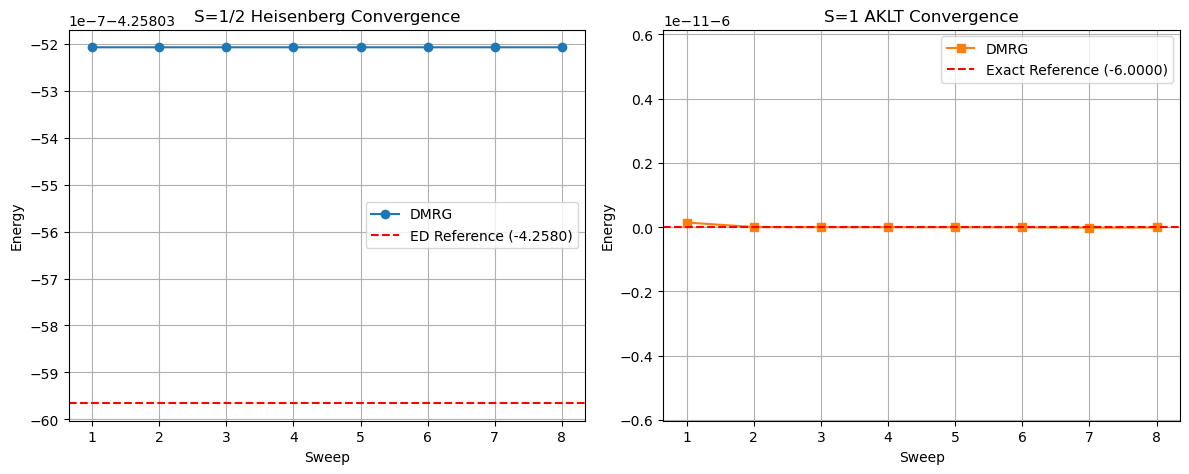

In [2]:
import numpy as np
import scipy.linalg
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
import os

# Create directory for figures
os.makedirs('figureAKLT', exist_ok=True)

# =====================================================================
# 1. Tensor Truncation & SVD
# =====================================================================
def truncate_svd(M, D_max, tol=1e-10, abs_tol=1e-14):
    """SVD Compression with absolute and relative tolerances."""
    try:
        U, S, Vh = scipy.linalg.svd(M, full_matrices=False)
    except scipy.linalg.LinAlgError:
        U, S, Vh = scipy.linalg.svd(M, full_matrices=False, lapack_driver='gesvd')
        
    if S[0] < abs_tol:
        D = 1
    else:
        cutoff = max(tol * S[0], abs_tol)
        D_kept = np.sum(S > cutoff)
        D = min(D_max, D_kept)
        D = max(1, D) # Ensure at least 1 state is kept
        
    trunc_err = np.sum(S[D:]**2)
    return U[:, :D], S[:D], Vh[:D, :], trunc_err

# =====================================================================
# 2. Physics & MPO Construction
# =====================================================================
def get_heisenberg_mpo(L, J=1.0, Jz=1.0):
    """Nearest-Neighbor S=1/2 Heisenberg MPO"""
    d = 2; Dw = 5
    Id = np.eye(2)
    Sp = np.array([[0, 1], [0, 0]])
    Sm = np.array([[0, 0], [1, 0]])
    Sz = np.array([[0.5, 0], [0, -0.5]])
    
    W = np.zeros((Dw, Dw, d, d), dtype=np.complex128)
    W[0, 0] = Id
    W[1, 0] = Sp
    W[2, 0] = Sm
    W[3, 0] = Sz
    W[4, 1] = (J/2) * Sm
    W[4, 2] = (J/2) * Sp
    W[4, 3] = Jz * Sz
    W[4, 4] = Id
    return [W.copy() for _ in range(L)], 4, 0

def get_aklt_mpo(L):
    """Exact AKLT S=1 MPO"""
    d = 3; Dw = 14
    Sx = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]) / np.sqrt(2)
    Sy = np.array([[0, -1j, 0], [1j, 0, -1j], [0, 1j, 0]]) / np.sqrt(2)
    Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
    
    S_vec = [Sx, Sy, Sz]
    Q_vec = [A @ B for A in S_vec for B in S_vec] 
    
    W = np.zeros((Dw, Dw, d, d), dtype=np.complex128)
    W[0, 0] = np.eye(3)
    for a in range(3): W[a+1, 0] = S_vec[a]
    for i in range(9): W[i+4, 0] = Q_vec[i]
    for a in range(3): W[13, a+1] = S_vec[a]
    for i in range(9): W[13, i+4] = (1.0/3.0) * Q_vec[i]
    W[13, 13] = np.eye(3)
    return [W.copy() for _ in range(L)], 13, 0

# =====================================================================
# 3. Fast BLAS Environment Updates (Replacing einsum with tensordot)
# =====================================================================
def update_L(L_old, A, W):
    """Left environment update using pure BLAS tensordot for speed."""
    T1 = np.tensordot(L_old, A, axes=([2], [0]))             # (b, x, t, Y)
    T2_raw = np.tensordot(T1, W, axes=([0, 2], [0, 3]))      # (x, Y, B, s)
    T2 = T2_raw.transpose(0, 3, 2, 1)                        # (x, s, B, Y)
    L_new_raw = np.tensordot(T2, A.conj(), axes=([0, 1], [0, 1])) # (B, Y, X)
    return L_new_raw.transpose(0, 2, 1)                      # (B, X, Y)

def update_R(R_old, B, W):
    """Right environment update using pure BLAS tensordot."""
    T1 = np.tensordot(R_old, B, axes=([2], [2]))             # (B, X, y, t)
    T2_raw = np.tensordot(T1, W, axes=([0, 3], [1, 3]))      # (X, y, b, s)
    T2 = T2_raw.transpose(0, 3, 2, 1)                        # (X, s, b, y)
    R_new_raw = np.tensordot(T2, B.conj(), axes=([0, 1], [2, 1])) # (b, y, x)
    return R_new_raw.transpose(0, 2, 1)                      # (b, x, y)

# =====================================================================
# 4. Single-Site DMRG Engine
# =====================================================================
class DMRGEngine:
    def __init__(self, W_list, b_left, b_right, d, D_max):
        self.L = len(W_list)
        self.W = W_list
        self.b_left = b_left
        self.b_right = b_right
        self.d = d
        self.D_max = D_max
        
        # Initialize MPS with random complex states
        self.MPS = []
        for i in range(self.L):
            D_l = min(d**i, d**(self.L - i), D_max)
            D_r = min(d**(i+1), d**(self.L - 1 - i), D_max)
            self.MPS.append(np.random.randn(D_l, d, D_r) + 1j * np.random.randn(D_l, d, D_r))
            
        # Right-canonicalize and normalize initial state
        for i in range(self.L - 1, 0, -1):
            Dl, d_phys, Dr = self.MPS[i].shape
            M_mat = self.MPS[i].reshape((Dl, d_phys * Dr), order='C')
            U, S, Vh, _ = truncate_svd(M_mat, self.D_max, tol=0)
            self.MPS[i] = Vh.reshape((len(S), d_phys, Dr), order='C')
            
            if i == 1:
                norm = np.linalg.norm(S)
                self.MPS[i-1] = np.tensordot(self.MPS[i-1], U @ np.diag(S/norm), axes=([2], [0]))
            else:
                self.MPS[i-1] = np.tensordot(self.MPS[i-1], U @ np.diag(S), axes=([2], [0]))
            
        # Initialize Environments
        Dw = self.W[0].shape[0]
        self.L_env = [None] * self.L
        self.R_env = [None] * self.L
        
        self.L_env[0] = np.zeros((Dw, 1, 1), dtype=np.complex128)
        self.L_env[0][self.b_left, 0, 0] = 1.0
        
        self.R_env[self.L - 1] = np.zeros((Dw, 1, 1), dtype=np.complex128)
        self.R_env[self.L - 1][self.b_right, 0, 0] = 1.0
        
        for i in range(self.L - 1, 0, -1):
            self.R_env[i-1] = update_R(self.R_env[i], self.MPS[i], self.W[i])

    def apply_Heff(self, v_flat, L_env, R_env, W, shape):
        V = v_flat.reshape(shape)
        T1 = np.tensordot(L_env, V, axes=([2], [0]))            # (b, x, t, Y)
        T2_raw = np.tensordot(T1, W, axes=([0, 2], [0, 3]))     # (x, Y, B, s)
        T2 = T2_raw.transpose(2, 0, 3, 1)                       # (B, x, s, Y)
        V_new = np.tensordot(T2, R_env, axes=([0, 3], [0, 2]))  # (x, s, X)
        return V_new.flatten()

    def optimize_site(self, i):
        shape = self.MPS[i].shape
        dim = np.prod(shape)
        matvec = lambda v: self.apply_Heff(v, self.L_env[i], self.R_env[i], self.W[i], shape)
        v0 = self.MPS[i].flatten()
        
        if dim <= 16:
            # Fallback for extremely small boundary matrices
            H_dense = np.zeros((dim, dim), dtype=np.complex128)
            for col in range(dim):
                vec = np.zeros(dim); vec[col] = 1.0
                H_dense[:, col] = matvec(vec)
            H_dense = 0.5 * (H_dense + H_dense.conj().T)
            evals, evecs = np.linalg.eigh(H_dense)
            return evals[0], evecs[:, 0].reshape(shape, order='C')
        else:
            # LinearOperator definition. Inform Scipy that it is mathematically Hermitian 
            Heff = LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec, dtype=np.complex128)
            try:
                evals, evecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-6, maxiter=200)
            except scipy.sparse.linalg.ArpackNoConvergence as e:
                evals = e.eigenvalues; evecs = e.eigenvectors
            return evals[0], evecs[:, 0].reshape(shape, order='C')

    def sweep(self):
        energies = []
        max_err = 0.0
        
        # Right Sweep
        for i in range(self.L - 1):
            energy, M_opt = self.optimize_site(i)
            energies.append(energy)
            
            Dl, d, Dr = M_opt.shape
            M_mat = M_opt.reshape((Dl * d, Dr), order='C')
            U, S, Vh, err = truncate_svd(M_mat, self.D_max)
            max_err = max(max_err, err)
            
            self.MPS[i] = U.reshape((Dl, d, len(S)), order='C')
            self.MPS[i+1] = np.tensordot(np.diag(S) @ Vh, self.MPS[i+1], axes=([1], [0]))
            self.L_env[i+1] = update_L(self.L_env[i], self.MPS[i], self.W[i])

        # Left Sweep
        for i in range(self.L - 1, 0, -1):
            energy, M_opt = self.optimize_site(i)
            energies.append(energy)
            
            Dl, d, Dr = M_opt.shape
            M_mat = M_opt.reshape((Dl, d * Dr), order='C')
            U, S, Vh, err = truncate_svd(M_mat, self.D_max)
            max_err = max(max_err, err)
            
            self.MPS[i] = Vh.reshape((len(S), d, Dr), order='C')
            self.MPS[i-1] = np.tensordot(self.MPS[i-1], U @ np.diag(S), axes=([2], [0]))
            self.R_env[i-1] = update_R(self.R_env[i], self.MPS[i], self.W[i])
            
        return np.mean(energies[-2:]), max_err


# =====================================================================
# 5. Execution & Plotting
# =====================================================================
def run_and_plot():
    import time
    L = 10
    sweeps = 8
    D_max = 30
    
    # ------------------ HEISENBERG MODEL ------------------
    print(f"--- S=1/2 Heisenberg Chain (L={L}) ---")
    start = time.time()
    W_heis, bl_heis, br_heis = get_heisenberg_mpo(L)
    dmrg_heis = DMRGEngine(W_heis, bl_heis, br_heis, d=2, D_max=D_max)
    
    heis_energies = []
    for s in range(sweeps):
        E, err = dmrg_heis.sweep()
        heis_energies.append(E.real)
        print(f"Sweep {s+1}/{sweeps} | Energy: {E.real:.8f} | Trunc Err: {err:.2e}")
    
    print(f"-> Time Elapsed: {time.time() - start:.2f} seconds")
    print(f"-> Target Exact Energy: -4.258035965\n")
    
    # ------------------ AKLT MODEL ------------------
    print(f"--- S=1 AKLT Model (L={L}) ---")
    start = time.time()
    W_aklt, bl_aklt, br_aklt = get_aklt_mpo(L)
    dmrg_aklt = DMRGEngine(W_aklt, bl_aklt, br_aklt, d=3, D_max=D_max)
    
    aklt_energies = []
    for s in range(sweeps):
        E, err = dmrg_aklt.sweep()
        aklt_energies.append(E.real)
        print(f"Sweep {s+1}/{sweeps} | Energy: {E.real:.8f} | Trunc Err: {err:.2e}")
        
    exact_aklt = -(L-1) * (2.0/3.0)
    print(f"-> Time Elapsed: {time.time() - start:.2f} seconds")
    print(f"-> Target Exact Energy: {exact_aklt:.8f}")
    
    # ------------------ PLOTTING ------------------
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, sweeps+1), heis_energies, marker='o', color='tab:blue', label='DMRG')
    plt.axhline(-4.258035965, color='red', linestyle='--', label='ED Reference (-4.2580)')
    plt.title('S=1/2 Heisenberg Convergence')
    plt.xlabel('Sweep'); plt.ylabel('Energy'); plt.legend(); plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, sweeps+1), aklt_energies, marker='s', color='tab:orange', label='DMRG')
    plt.axhline(exact_aklt, color='red', linestyle='--', label=f'Exact Reference ({exact_aklt:.4f})')
    plt.title('S=1 AKLT Convergence')
    plt.xlabel('Sweep'); plt.ylabel('Energy'); plt.legend(); plt.grid(True)
    
    plt.tight_layout()
    save_path = os.path.join('figureAKLT', 'DMRG_convergence.png')
    plt.savefig(save_path, dpi=300)
    print(f"\nFigure saved to: {save_path}")
    plt.show()

if __name__ == '__main__':
    run_and_plot()